# Analyze fitness effects

Import Python modules

In [2]:
import os
import glob
import pandas as pd
import numpy as np
import glob
from collections import defaultdict
import math
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(font_scale=1.0, style='ticks', palette='colorblind')
import scipy
from Bio import SeqIO
from Bio.Seq import Seq

Read in data

In [12]:
# Read in fitness effects of amino-acid mutations
fitness_df = pd.read_csv('../results/aa_fitness_effects.csv', keep_default_na=False)

# Read in data on fitness effects of synonymous mutations at a given site
site_syn_fitness_df = pd.read_csv('../results/sitewise_synonymous_fitness_effects.csv', keep_default_na=False)

In [26]:
fitness_df.head()

,subtype,segment,gene,codon_site,wt_aa,mut_aa,aa_mut,mut_class,actual_count,expected_count,delta_fitness
0,H1,HA,HA,2,K,M,K2M,nonsynonymous,14,32.825608,-0.832177
1,H1,HA,HA,3,A,A,A3A,synonymous,37,22.921977,0.470666
2,H1,HA,HA,4,I,L,I4L,nonsynonymous,6,25.004579,-1.367056
3,H1,HA,HA,5,L,L,L5L,synonymous,9,26.267859,-1.035910
4,H1,HA,HA,6,V,V,V6V,synonymous,16,26.010929,-0.474197


Plot the distribution of effects

40080


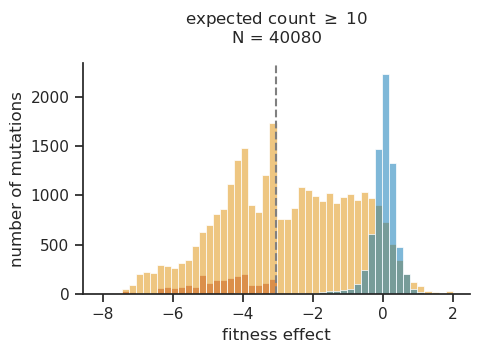

In [ ]:
mut_class_colors = {
    'synonymous' : '#0173b2',
    'nonsynonymous' : '#de8f05',
    'nonsense' : 'firebrick',
}

count_threshold = 10
data = fitness_df[
    # (fitness_df['gene'] == 'HA') &
    # (fitness_df['subtype'] == 'H3') &
    (fitness_df['expected_count'] >= count_threshold)
].copy()
print(len(data))
fitness_lod = np.log(0.5/(count_threshold+0.5))
data['delta_fitness'] = data['delta_fitness'].clip(upper=2.0)
plt.figure(figsize=(5,3))
ax = sns.histplot(
    x='delta_fitness', data=data, bins=50,
    hue='mut_class', hue_order=['synonymous', 'nonsynonymous', 'nonsense'],
    palette=mut_class_colors, legend=False
)
plt.axvline(fitness_lod, color='gray', linestyle='--')
plt.xlabel('fitness effect')
plt.ylabel('number of mutations')
plt.title(f'expected count $\geq$ {count_threshold}\nN = {len(data)}', y=1.05)
sns.despine()
plt.show()

Plot distributions of fitness effects as a function of gene.

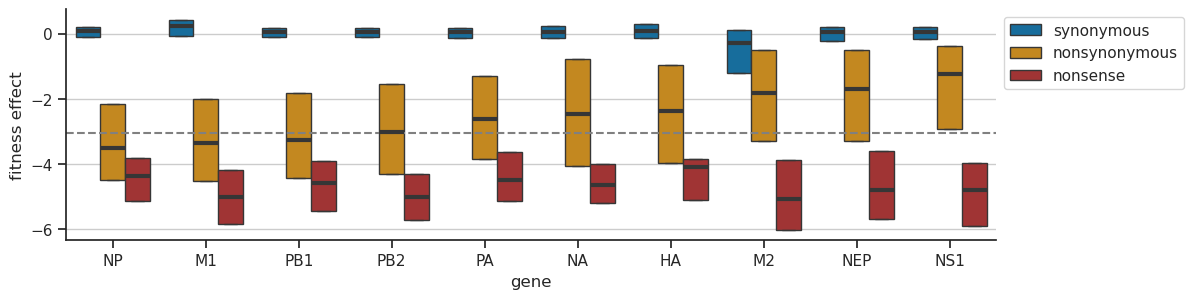

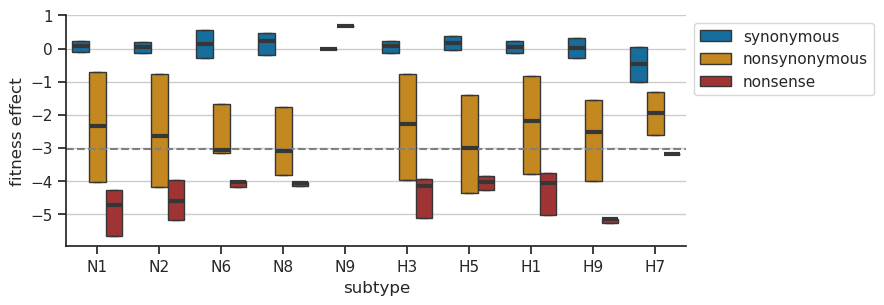

In [21]:
# Get data
count_threshold = 10
data = fitness_df[fitness_df['expected_count'] >= count_threshold].copy()
fitness_lod = np.log(0.5/(count_threshold+0.5))

# TODO: remove
data['gene'] = data['gene'].apply(lambda x: x.upper())
data = data[data['gene'] != 'PB1;PB1-F2']

# Explode dataframe so that there is one row per mutation per gene
data['gene'] = data['gene'].str.split(';')
data['codon_site'] = data['codon_site'].str.split(';')
data = data.explode(['gene', 'codon_site'])

# Sort dataframe by median delta_fitness of nonsynonymous mutations
nonsynonymous_medians = (
    data[data['mut_class'] == 'nonsynonymous']
    .groupby('gene', as_index=False)['delta_fitness']
    .median()
    .sort_values('delta_fitness')
    .rename(columns={'delta_fitness':'median_nonsyn_fitness'})
)
data = (
    data
    .merge(nonsynonymous_medians)
    .sort_values('median_nonsyn_fitness', ascending=True)
)

# Plot data
plt.figure(figsize=[12,3])
sns.boxplot(
    x='gene', y='delta_fitness', data=data,
    hue='mut_class', hue_order=['synonymous', 'nonsynonymous', 'nonsense'],
    palette=mut_class_colors,
    medianprops={"linewidth": 3}, showfliers=False, whis=(50,50)
)
plt.axhline(fitness_lod, color='gray', linestyle='--')
plt.grid(axis='y')
plt.legend(bbox_to_anchor=(1,1))
plt.ylabel('fitness effect')
sns.despine()
plt.show()

# Plot distributions for different HA and NA subtypes
ha_na_data = data[data['gene'].isin(['HA', 'NA'])].copy()
plt.figure(figsize=[8,3])
sns.boxplot(
    x='subtype', y='delta_fitness', data=ha_na_data,
    hue='mut_class', hue_order=['synonymous', 'nonsynonymous', 'nonsense'],
    palette=mut_class_colors,
    medianprops={"linewidth": 3}, showfliers=False, whis=(50,50)
)
plt.axhline(fitness_lod, color='gray', linestyle='--')
plt.grid(axis='y')
plt.legend(bbox_to_anchor=(1,1))
plt.ylabel('fitness effect')
sns.despine()
plt.show()

Examine the fitness effects of synonymous mutation across the genome.

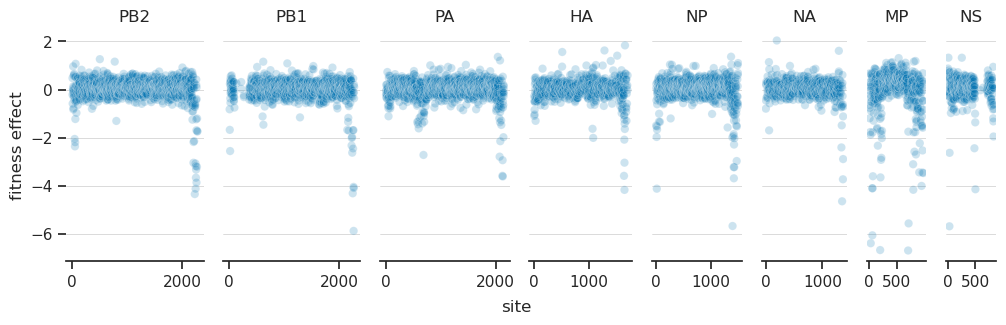

In [ ]:
# Get data
count_threshold = 25
mut_classes_to_plot = ['synonymous']
syn_data = site_syn_fitness_df[
    (site_syn_fitness_df['subtype'].isin(['all', 'H1', 'N1'])) &
    (site_syn_fitness_df['mut_class'].isin(mut_classes_to_plot)) &
    (site_syn_fitness_df['expected_count'] >= count_threshold)
].copy()

# Get width ratios for plotting segments
segments = ['PB2', 'PB1', 'PA', 'HA', 'NP', 'NA', 'MP', 'NS']
width_ratios = []
for segment in segments:
    # TODO: update with more accurate width ratios
    data = site_syn_fitness_df[site_syn_fitness_df['segment'] == segment]
    width_ratios.append(data['site'].max())

# Plot data
(fig, axs) = plt.subplots(
    ncols=len(segments), sharey=True, figsize=[12, 3],
    gridspec_kw={'width_ratios': width_ratios}
)
for (i, segment) in enumerate(segments):
    data = syn_data[(syn_data['segment'] == segment)]
    sns.scatterplot(
        x='site', y='delta_fitness', data=data, ax=axs[i], alpha=0.2,
        hue='mut_class', palette=mut_class_colors
    )
    axs[i].grid(axis='y', which='both', lw=0.5)
    axs[i].set(title=segment, xlabel='')
    axs[i].get_legend().remove()
    if i > 0:
        axs[i].tick_params(axis='y', which='both', left=False, labelleft=False)
    if segment in ['MP', 'NS']:
        axs[i].set(xticks=[0, 500])
    sns.despine(left=True, ax=axs[i])

axs[0].set(ylabel='fitness effect')
fig.text(0.5, -0.06, 'site', ha='center')
plt.show()

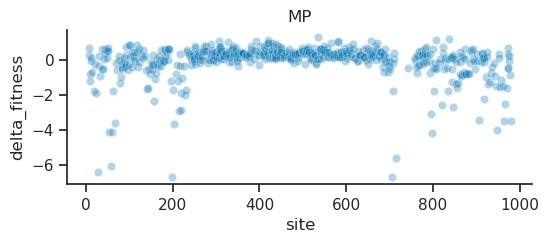

In [25]:
segment = 'MP'
data = syn_data[(syn_data['segment'] == segment)]
plt.figure(figsize=[6,2])
sns.scatterplot(x='site', y='delta_fitness', data=data, alpha=0.3)
plt.title(segment)
sns.despine()
plt.show()

Compare fitness effects to DMS data for HA.

In [42]:
# Read in numbering scheme
ha_numbering_data = pd.read_csv('../results/dms_data/Yu_HA/numbering_map.csv')
del ha_numbering_data['region']
del ha_numbering_data['rbs_region']

# Get fitness data
count_threshold = 10
fitness_lod = np.log(0.5/(count_threshold+0.5))
fitness_data = fitness_df[
    (fitness_df['expected_count'] >= count_threshold) &
    (fitness_df['gene'] == 'HA') &
    (fitness_df['subtype'] == 'H3')
].copy()
fitness_data['codon_site'] = fitness_data['codon_site'].astype(int)

# Read in DMS data and merge with numbering data and fitness data
f = '../data/dms_data/Yu_HA/Phenotypes.csv'
ha_dms_data = (
    pd.read_csv(f)
    .rename(
        columns={
            'MDCKSIAT1 cell entry' : 'cell_entry',
            'sera escape' : 'sera_escape',
            'pH stability' : 'pH_stability',
            'wildtype' : 'wt_aa',
            'mutant' : 'mut_aa',
            'nt changes to codon' : 'n_nt_changes'
        }
    )
    .merge(ha_numbering_data, on='sequential_site', validate='many_to_one')
    .rename(columns={'tree_reference_site' : 'codon_site'})
    .merge(fitness_data, on=['codon_site', 'wt_aa', 'mut_aa'], how='inner')
    .sort_values('codon_site')
)

data = ha_dms_data[ha_dms_data['cell_entry'].notnull() & ha_dms_data['delta_fitness'].notnull()]
print('N muts with data:', len(data))
print('N sites with data:', data['codon_site'].nunique())
data.head()

N muts with data: 2506
N sites with data: 504


,site,wt_aa,mut_aa,sera_escape,cell_entry,pH_stability,sequential_site,region,n_nt_changes,codon_site,reference_site,sequential_wt,subtype,segment,gene,aa_mut,mut_class,actual_count,expected_count_gw,expected_count,delta_fitness_gw,delta_fitness
1,1,Q,K,0.04918,-0.1115,0.001008,1,HA1,1,17,1,Q,H3,HA,HA,Q17K,nonsynonymous,55,63.685171,41.032524,-0.145389,0.289906
0,1,Q,H,0.03837,-0.2349,-0.004620,1,HA1,1,17,1,Q,H3,HA,HA,Q17H,nonsynonymous,6,29.339585,17.834674,-1.524034,-1.036992
3,1,Q,R,-0.19230,-0.8861,0.012610,1,HA1,1,17,1,Q,H3,HA,HA,Q17R,nonsynonymous,17,108.058060,44.263436,-1.825084,-0.939191
2,1,Q,L,-0.16660,-1.5680,0.033410,1,HA1,1,17,1,Q,H3,HA,HA,Q17L,nonsynonymous,2,17.494230,11.649863,-1.973760,-1.581027
4,1,Q,Q,0.00000,0.0000,0.000000,1,HA1,0,17,1,Q,H3,HA,HA,Q17Q,synonymous,73,109.166994,81.377565,-0.400163,-0.107940


Plot the correlation between fitness effects and DMS phenotypes.

cell_entry
r all: 0.799758805063673
r nonsyn: 0.7535669198317985


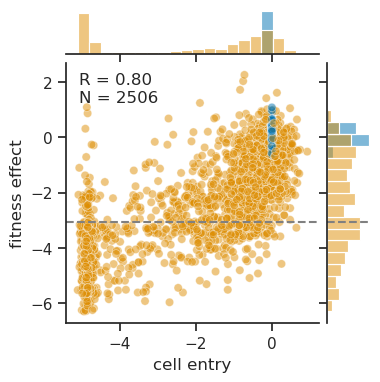

pH_stability
r all: 0.4061059288021262
r nonsyn: 0.34054520916101017


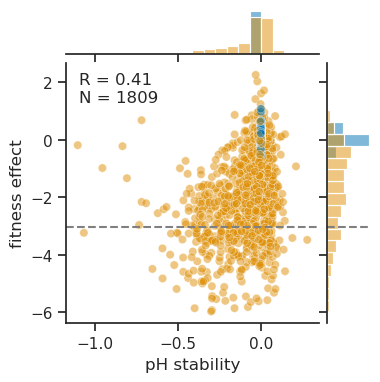

sera_escape
r all: 0.0570735791692192
r nonsyn: 0.007194851240708936


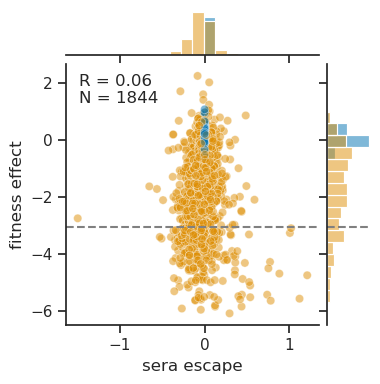

In [43]:
dms_metrics = ['cell_entry', 'pH_stability', 'sera_escape']
for dms_metric in dms_metrics:

    data = ha_dms_data[(ha_dms_data[dms_metric].notnull()) & (ha_dms_data['delta_fitness'].notnull())]
    r = data[dms_metric].corr(data['delta_fitness'])
    nonsyn_data = data[data['mut_class'] == 'nonsynonymous']
    r_nonsyn = nonsyn_data[dms_metric].corr(nonsyn_data['delta_fitness'])
    print(dms_metric)
    print('r all:', r)
    print('r nonsyn:', r_nonsyn)

    g = sns.JointGrid(data=data, x=dms_metric, y='delta_fitness', hue='mut_class', palette=mut_class_colors, height=4)
    g.plot_joint(sns.scatterplot, alpha=0.5, legend=False)
    g.ax_joint.annotate(f'R = {r:.2f}\nN = {len(data)}', xy=(0.05, 0.85), xycoords='axes fraction', fontsize=12)
    g.ax_joint.axhline(y=fitness_lod, color='gray', linestyle='--')
    g.ax_joint.set(xlabel=dms_metric.replace('_', ' '), ylabel='fitness effect')
    
    g.plot_marginals(sns.histplot, bins=20)
    g.ax_marg_y.axhline(y=fitness_lod, color='gray', linestyle='--')
    
    plt.show()

Compare fitness effects to DMS data for NP.

In [52]:
# Get fitness data
count_threshold = 25
fitness_lod = np.log(0.5/(count_threshold+0.5))
fitness_data = fitness_df[
    (fitness_df['gene'] == 'NP') &
    (fitness_df['expected_count'] >= count_threshold) &
    (fitness_df['subtype'] == 'all')
].copy()
fitness_data['codon_site'] = fitness_data['codon_site'].astype(int)

# Read in data and merge with fitness data. The sites are indexed in the exact same way.
np_dms_data = (
    pd.read_csv('../results/dms_data/Bloom_NP/processed_dms_data.csv')
    .rename(columns={'site':'codon_site'})
    .merge(fitness_data, on=['codon_site', 'wt_aa', 'mut_aa'], how='inner')
    .sort_values('codon_site')
)

print(len(np_dms_data))
np_dms_data

2235


,codon_site,wt_aa,mut_aa,preference,wt_preference,dms_effect,subtype,segment,gene,aa_mut,mut_class,actual_count,expected_count_gw,expected_count,delta_fitness_gw,delta_fitness
701,1,M,I,0.023434,0.391903,-2.816809,all,NP,NP,M1I,nonsynonymous,0,344.843419,280.258826,-6.537687,-6.330643
1845,1,M,T,0.032492,0.391903,-2.490014,all,NP,NP,M1T,nonsynonymous,0,140.589400,98.020302,-5.642541,-5.283410
871,1,M,K,0.038531,0.391903,-2.319554,all,NP,NP,M1K,nonsynonymous,0,23.987520,30.577082,-3.891311,-4.129618
1846,2,A,T,0.004529,0.753436,-5.114244,all,NP,NP,A2T,nonsynonymous,8,291.386249,348.754772,-3.536298,-3.715735
1983,2,A,V,0.080349,0.753436,-2.238261,all,NP,NP,A2V,nonsynonymous,66,178.159868,329.840440,-0.988282,-1.602922
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1044,498,N,K,0.276824,0.088315,1.142474,all,NP,NP,N498K,nonsynonymous,16,38.327400,34.488234,-0.855766,-0.751651
1372,498,N,N,0.088315,0.088315,0.000000,all,NP,NP,N498N,synonymous,88,128.726884,147.847127,-0.378567,-0.516552
870,498,N,I,0.073817,0.088315,-0.179316,all,NP,NP,N498I,nonsynonymous,17,20.705390,26.105767,-0.192055,-0.418927
248,498,N,D,0.001553,0.088315,-4.040906,all,NP,NP,N498D,nonsynonymous,4,127.892699,72.076988,-3.351016,-2.780570


Plot the correlation between fitness effects and DMS effects.

r all: 0.6925409555081208
r nonsyn: 0.4662648382278852


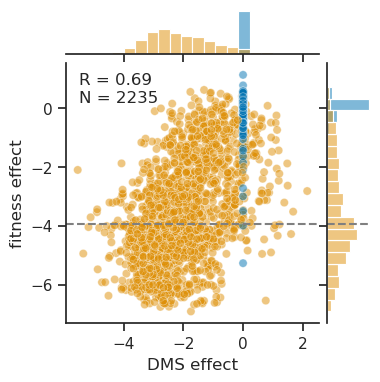

In [54]:
r = np_dms_data['dms_effect'].corr(np_dms_data['delta_fitness'])
nonsyn_data = np_dms_data[np_dms_data['mut_class'] == 'nonsynonymous']
r_nonsyn = nonsyn_data['dms_effect'].corr(nonsyn_data['delta_fitness'])
print('r all:', r)
print('r nonsyn:', r_nonsyn)

g = sns.JointGrid(data=np_dms_data, x='dms_effect', y='delta_fitness', hue='mut_class', palette=mut_class_colors, height=4)
g.plot_joint(sns.scatterplot, alpha=0.5, legend=False)
g.ax_joint.annotate(f'R = {r:.2f}\nN = {len(np_dms_data)}', xy=(0.05, 0.85), xycoords='axes fraction', fontsize=12)
g.ax_joint.axhline(y=fitness_lod, color='gray', linestyle='--')
g.ax_joint.set(xlabel='DMS effect', ylabel='fitness effect')

g.plot_marginals(sns.histplot, bins=20)
g.ax_marg_y.axhline(y=fitness_lod, color='gray', linestyle='--')

# plt.title('NP (Bloom, 2014)')
plt.show()

Compare fitness effects to DMS data for PB2.

In [55]:
# Get fitness data
count_threshold = 25
fitness_lod = np.log(0.5/(count_threshold+0.5))
fitness_data = fitness_df[
    (fitness_df['gene'] == 'PB2') &
    (fitness_df['expected_count'] >= count_threshold) &
    (fitness_df['subtype'] == 'all')
].copy()
fitness_data['codon_site'] = fitness_data['codon_site'].astype(int)

# Read in the DMS data and merge with the fitness data
pb2_dms_data = (
    pd.read_csv('../data/dms_data/Soh_PB2/elife-45079-fig2-data1-v1.csv')
    .rename(columns={
        'site':'codon_site',
        'wildtype' : 'wt_aa', 
        'mutation' : 'mut_aa',
    })
    .merge(fitness_data, on=['codon_site', 'wt_aa', 'mut_aa'], how='inner')
    .sort_values('codon_site')
)

pb2_dms_data

,codon_site,wt_aa,mut_aa,prefA549,prefCCL141,log2prefA549,log2prefCCL141,effectA549,effectCCL141,log2effectA549,log2effectCCL141,mutdiffsel,Known human adaptive,Experimentally adaptive in,subtype,segment,gene,aa_mut,mut_class,actual_count,expected_count_gw,expected_count,delta_fitness_gw,delta_fitness
2730,1,M,T,0.037434,0.052167,-4.739489,-4.260707,0.076396,0.144040,-3.710360,-2.795457,-0.741288,No,NaN,all,PB2,PB2,M1T,nonsynonymous,0,140.872669,91.969550,-5.644547,-5.220027
997,1,M,I,0.051935,0.048641,-4.267144,-4.361682,0.105989,0.134303,-3.238015,-2.896432,0.077020,No,NaN,all,PB2,PB2,M1I,nonsynonymous,10,345.538234,255.731331,-3.495174,-3.194705
692,2,E,G,0.028171,0.012344,-5.149633,-6.340091,0.152174,0.079186,-2.716206,-3.658605,2.084471,No,NaN,all,PB2,PB2,E2G,nonsynonymous,12,139.721051,206.702469,-2.417491,-2.807968
385,2,E,E,0.185125,0.155881,-2.433427,-2.681487,1.000000,1.000000,0.000000,0.000000,NaN,No,NaN,all,PB2,PB2,E2E,synonymous,228,220.074412,214.494117,0.035301,0.060926
225,2,E,D,0.050450,0.051871,-4.308996,-4.268940,0.272519,0.332758,-1.875570,-1.587454,0.985515,No,NaN,all,PB2,PB2,E2D,nonsynonymous,21,46.010768,38.096479,-0.771631,-0.585108
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1261,758,I,I,0.207929,0.304852,-2.265838,-1.713819,1.000000,1.000000,0.000000,0.000000,NaN,No,NaN,all,PB2,PB2,I758I,synonymous,51,260.819300,174.691076,-1.624161,-1.224295
1507,759,N,K,0.156513,0.253609,-2.675648,-1.979323,0.688408,0.783905,-0.538664,-0.351249,-0.286214,No,NaN,all,PB2,PB2,N759K,nonsynonymous,35,41.821327,31.286784,-0.175758,0.110482
2053,759,N,N,0.227355,0.323520,-2.136984,-1.628074,1.000000,1.000000,0.000000,0.000000,NaN,No,NaN,all,PB2,PB2,N759N,synonymous,25,140.737382,151.346765,-1.711764,-1.784193
2729,759,N,S,0.021941,0.026562,-5.510203,-5.234506,0.096507,0.082102,-3.373219,-3.606432,0.286220,No,NaN,all,PB2,PB2,N759S,nonsynonymous,5,139.929786,146.826684,-3.239960,-3.287904


Plot the correlation between fitness effects and DMS effects.

log2effectA549
r all: 0.7444094890839031
r nonsyn: 0.6085561242773723


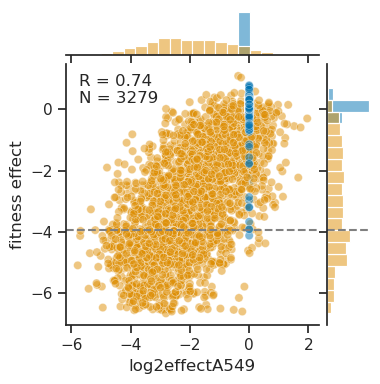

log2effectCCL141
r all: 0.7230990903570607
r nonsyn: 0.6043771664162251


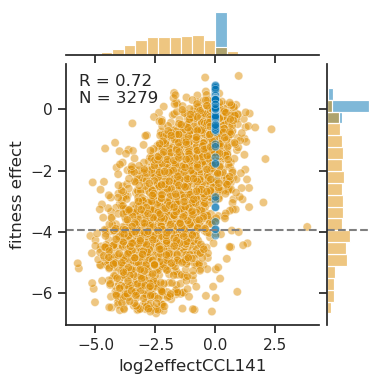

In [128]:
dms_metrics = ['log2effectA549', 'log2effectCCL141']
for dms_metric in dms_metrics:

    data = pb2_dms_data[(pb2_dms_data[dms_metric].notnull()) & (pb2_dms_data['delta_fitness'].notnull())]
    r = data[dms_metric].corr(data['delta_fitness'])
    nonsyn_data = data[data['mut_class'] == 'nonsynonymous']
    r_nonsyn = nonsyn_data[dms_metric].corr(nonsyn_data['delta_fitness'])
    print(dms_metric)
    print('r all:', r)
    print('r nonsyn:', r_nonsyn)

    g = sns.JointGrid(data=data, x=dms_metric, y='delta_fitness', hue='mut_class', palette=mut_class_colors, height=4)
    g.plot_joint(sns.scatterplot, alpha=0.5, legend=False)
    g.ax_joint.annotate(f'R = {r:.2f}\nN = {len(data)}', xy=(0.05, 0.85), xycoords='axes fraction', fontsize=12)
    g.ax_joint.axhline(y=fitness_lod, color='gray', linestyle='--')
    g.ax_joint.set(xlabel=dms_metric.replace('_', ' '), ylabel='fitness effect')
    
    g.plot_marginals(sns.histplot, bins=20)
    g.ax_marg_y.axhline(y=fitness_lod, color='gray', linestyle='--')
    
    plt.show()